### Importing Dependencies

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import re
import os

# Download NLTK data
nltk.download('punkt', quiet=True)

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.20.0


### Loading Data

In [3]:
# Load your dataset
file_path = 'D:\English_to_hindi_translation\Data\Dataset_English_Hindi.csv'  # Update this path

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"✅ Dataset loaded successfully!")
    print(f"📊 Dataset shape: {df.shape}")
    print(f"\n📋 Column names: {df.columns.tolist()}")
    print(f"\n👀 First 5 rows:")
    print(df.head())
    print(f"\n📈 Dataset info:")
    print(df.info())
else:
    print(f"❌ File not found at {file_path}")
    # Try to find CSV in current directory
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
    if csv_files:
        print(f"Found CSV files in current directory: {csv_files}")
        file_path = csv_files[0]
        df = pd.read_csv(file_path)
        print(f"\n✅ Loaded: {file_path}")
        print(df.head())
    else:
        raise FileNotFoundError("No CSV file found! Please check the file path.")

<>:2: SyntaxWarning: invalid escape sequence '\E'
<>:2: SyntaxWarning: invalid escape sequence '\E'
C:\Users\hb292\AppData\Local\Temp\ipykernel_18400\2335990538.py:2: SyntaxWarning: invalid escape sequence '\E'
  file_path = 'D:\English_to_hindi_translation\Data\Dataset_English_Hindi.csv'  # Update this path


✅ Dataset loaded successfully!
📊 Dataset shape: (130476, 2)

📋 Column names: ['English', 'Hindi']

👀 First 5 rows:
  English    Hindi
0   Help!    बचाओ!
1   Jump.    उछलो.
2   Jump.    कूदो.
3   Jump.   छलांग.
4  Hello!  नमस्ते।

📈 Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 130476 entries, 0 to 130475
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   English  130474 non-null  str  
 1   Hindi    130164 non-null  str  
dtypes: str(2)
memory usage: 40.3 MB
None


In [4]:
# Interactive column selection
print("📝 Column Selection")
print("-" * 40)
print(f"Available columns: {df.columns.tolist()}")

# Try to automatically detect columns
english_col = None
hindi_col = None

# Common column name patterns
en_patterns = ['english', 'English', 'en', 'source', 'input', 'text', 'eng']
hi_patterns = ['hindi', 'Hindi', 'hi', 'target', 'output', 'translation', 'hin']

for col in df.columns:
    if col.lower() in en_patterns:
        english_col = col
    if col.lower() in hi_patterns:
        hindi_col = col

# If not found, ask user
if english_col is None or hindi_col is None:
    print("\n⚠️ Could not automatically detect columns.")
    english_col = input("Enter the English column name: ")
    hindi_col = input("Enter the Hindi column name: ")

print(f"\n✅ Using:")
print(f"   English column: '{english_col}'")
print(f"   Hindi column: '{hindi_col}'")

# Quick preview
print(f"\n📝 Sample data:")
print(f"English: {df[english_col].iloc[0]}")
print(f"Hindi: {df[hindi_col].iloc[0]}")

# Remove missing values
initial_len = len(df)
df = df.dropna(subset=[english_col, hindi_col])
print(f"\n🗑️ Removed {initial_len - len(df)} rows with missing values")
print(f"✅ Final dataset size: {len(df)} pairs")

📝 Column Selection
----------------------------------------
Available columns: ['English', 'Hindi']

✅ Using:
   English column: 'English'
   Hindi column: 'Hindi'

📝 Sample data:
English: Help!
Hindi: बचाओ!

🗑️ Removed 314 rows with missing values
✅ Final dataset size: 130162 pairs


🔄 Cleaning texts...
📊 Text Length Analysis:
----------------------------------------
English - Mean: 14.7, Max: 398, 95th percentile: 37
Hindi - Mean: 16.5, Max: 417, 95th percentile: 42


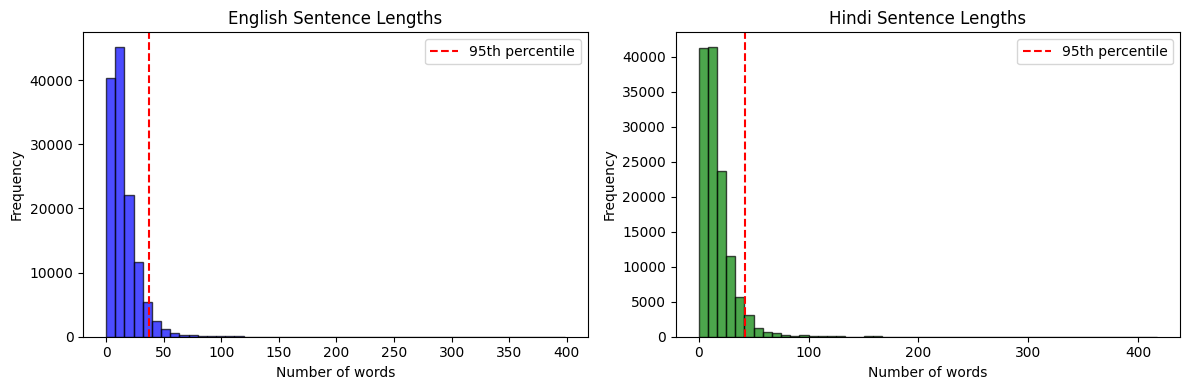


✅ After cleaning: 130105 sentence pairs

📝 Sample after cleaning:
English: help
Hindi: बचाओ
Decoder input: start बचाओ
Decoder output: बचाओ end


In [5]:
def clean_text(text):
    """Clean and normalize text"""
    if isinstance(text, str):
        # Convert to lowercase
        text = text.lower()
        # Remove special characters but keep Hindi characters (Unicode range: 0900-097F)
        text = re.sub(r'[^a-zA-Z\s\u0900-\u097F]', '', text)
        # Remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()
    return text

def add_start_end_tokens(text):
    """Add start and end tokens for decoder"""
    return f"start {text} end"

def analyze_text_lengths(df, english_col, hindi_col):
    """Analyze text lengths for setting max sequence lengths"""
    en_lengths = df[english_col].astype(str).str.split().str.len()
    hi_lengths = df[hindi_col].astype(str).str.split().str.len()
    
    print("📊 Text Length Analysis:")
    print("-" * 40)
    print(f"English - Mean: {en_lengths.mean():.1f}, Max: {en_lengths.max()}, 95th percentile: {en_lengths.quantile(0.95):.0f}")
    print(f"Hindi - Mean: {hi_lengths.mean():.1f}, Max: {hi_lengths.max()}, 95th percentile: {hi_lengths.quantile(0.95):.0f}")
    
    # Plot distributions
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(en_lengths, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title('English Sentence Lengths')
    axes[0].set_xlabel('Number of words')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(en_lengths.quantile(0.95), color='red', linestyle='--', label='95th percentile')
    axes[0].legend()
    
    axes[1].hist(hi_lengths, bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1].set_title('Hindi Sentence Lengths')
    axes[1].set_xlabel('Number of words')
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(hi_lengths.quantile(0.95), color='red', linestyle='--', label='95th percentile')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return int(en_lengths.quantile(0.95)), int(hi_lengths.quantile(0.95))

# Clean the texts
print("🔄 Cleaning texts...")
df['clean_english'] = df[english_col].apply(clean_text)
df['clean_hindi'] = df[hindi_col].apply(clean_text)

# Analyze lengths to determine optimal max sequence lengths
max_en_len, max_hi_len = analyze_text_lengths(df, 'clean_english', 'clean_hindi')

# Add start/end tokens for decoder
df['decoder_input'] = df['clean_hindi'].apply(lambda x: f"start {x}")
df['decoder_output'] = df['clean_hindi'].apply(lambda x: f"{x} end")

# Remove empty sentences
df = df[df['clean_english'].str.len() > 0]
df = df[df['clean_hindi'].str.len() > 0]

print(f"\n✅ After cleaning: {len(df)} sentence pairs")
print(f"\n📝 Sample after cleaning:")
print(f"English: {df['clean_english'].iloc[0]}")
print(f"Hindi: {df['clean_hindi'].iloc[0]}")
print(f"Decoder input: {df['decoder_input'].iloc[0]}")
print(f"Decoder output: {df['decoder_output'].iloc[0]}")

In [6]:
# Model parameters - Adjust these based on your dataset and available memory
class ModelConfig:
    # Sequence lengths
    MAX_SEQ_LEN_INPUT = min(20, max_en_len)  # English max length
    MAX_SEQ_LEN_OUTPUT = min(25, max_hi_len)  # Hindi max length
    
    # Vocabulary sizes
    VOCAB_SIZE_INPUT = 5000   # Max English words
    VOCAB_SIZE_OUTPUT = 5000  # Max Hindi words
    
    # Model architecture
    EMBEDDING_DIM = 256       # Embedding dimension
    HIDDEN_UNITS = 512        # LSTM hidden units
    
    # Training
    BATCH_SIZE = 64
    EPOCHS = 30
    VALIDATION_SPLIT = 0.2
    EARLY_STOPPING_PATIENCE = 5

print("📋 Model Configuration:")
print("-" * 40)
for key, value in ModelConfig.__dict__.items():
    if not key.startswith('_'):
        print(f"{key}: {value}")

📋 Model Configuration:
----------------------------------------
MAX_SEQ_LEN_INPUT: 20
MAX_SEQ_LEN_OUTPUT: 25
VOCAB_SIZE_INPUT: 5000
VOCAB_SIZE_OUTPUT: 5000
EMBEDDING_DIM: 256
HIDDEN_UNITS: 512
BATCH_SIZE: 64
EPOCHS: 30
VALIDATION_SPLIT: 0.2
EARLY_STOPPING_PATIENCE: 5


In [7]:
def prepare_sequences(df, config):
    """Prepare sequences for training"""
    
    print("🔄 Creating tokenizers...")
    
    # Create tokenizers
    input_tokenizer = Tokenizer(num_words=config.VOCAB_SIZE_INPUT, filters='', lower=True)
    output_tokenizer = Tokenizer(num_words=config.VOCAB_SIZE_OUTPUT, filters='', lower=True)
    
    # Fit tokenizers on data
    input_tokenizer.fit_on_texts(df['clean_english'])
    output_tokenizer.fit_on_texts(df['decoder_input'])
    
    # Convert texts to sequences
    print("Converting to sequences...")
    input_sequences = input_tokenizer.texts_to_sequences(df['clean_english'])
    decoder_input_sequences = output_tokenizer.texts_to_sequences(df['decoder_input'])
    decoder_output_sequences = output_tokenizer.texts_to_sequences(df['decoder_output'])
    
    # Pad sequences
    encoder_input_data = pad_sequences(input_sequences, maxlen=config.MAX_SEQ_LEN_INPUT, padding='post')
    decoder_input_data = pad_sequences(decoder_input_sequences, maxlen=config.MAX_SEQ_LEN_OUTPUT, padding='post')
    decoder_output_data = pad_sequences(decoder_output_sequences, maxlen=config.MAX_SEQ_LEN_OUTPUT, padding='post')
    
    # Reshape decoder output for sparse categorical crossentropy
    decoder_output_data = np.expand_dims(decoder_output_data, -1)
    
    # Actual vocabulary sizes (may be smaller than max)
    vocab_size_input = min(config.VOCAB_SIZE_INPUT, len(input_tokenizer.word_index) + 1)
    vocab_size_output = min(config.VOCAB_SIZE_OUTPUT, len(output_tokenizer.word_index) + 1)
    
    print(f"\n✅ Data preparation complete!")
    print(f"Encoder input shape: {encoder_input_data.shape}")
    print(f"Decoder input shape: {decoder_input_data.shape}")
    print(f"Decoder output shape: {decoder_output_data.shape}")
    print(f"Input vocabulary size: {vocab_size_input}")
    print(f"Output vocabulary size: {vocab_size_output}")
    
    return (encoder_input_data, decoder_input_data, decoder_output_data,
            input_tokenizer, output_tokenizer, vocab_size_input, vocab_size_output)

# Prepare sequences
(encoder_input_data, decoder_input_data, decoder_output_data,
 input_tokenizer, output_tokenizer, vocab_size_input_actual,
 vocab_size_output_actual) = prepare_sequences(df, ModelConfig)

# Update config with actual vocabulary sizes
ModelConfig.VOCAB_SIZE_INPUT = vocab_size_input_actual
ModelConfig.VOCAB_SIZE_OUTPUT = vocab_size_output_actual

🔄 Creating tokenizers...
Converting to sequences...

✅ Data preparation complete!
Encoder input shape: (130105, 20)
Decoder input shape: (130105, 25)
Decoder output shape: (130105, 25, 1)
Input vocabulary size: 5000
Output vocabulary size: 5000


In [8]:
def create_model(vocab_size_input, vocab_size_output, max_seq_length_input, 
                 max_seq_length_output, embedding_dim, hidden_units):
    """
    Create Seq2Seq model for translation
    """
    # Define encoder input layer
    encoder_inputs = Input(shape=(max_seq_length_input,))
    
    # Define encoder embedding layer
    encoder_embedding = Embedding(input_dim=vocab_size_input, 
                                  output_dim=embedding_dim)(encoder_inputs)
    
    # Define encoder LSTM layer
    encoder_lstm = LSTM(hidden_units, return_state=True)
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
    
    # Discard encoder outputs and keep only the states
    encoder_states = [state_h, state_c]
    
    # Define decoder input layer
    decoder_inputs = Input(shape=(max_seq_length_output,))
    
    # Define decoder embedding layer
    decoder_embedding = Embedding(input_dim=vocab_size_output, 
                                  output_dim=embedding_dim)(decoder_inputs)
    
    # Define decoder LSTM layer with initial state set to encoder states
    decoder_lstm = LSTM(hidden_units, return_sequences=True, return_state=True)
    decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
    
    # Define decoder output layer
    decoder_dense = Dense(vocab_size_output, activation='softmax')
    decoder_outputs = decoder_dense(decoder_outputs)
    
    # Define the model
    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
    print(model.summary())
    return model

# Create the model
print("🏗️ Building Seq2Seq model...")
model = create_model(
    vocab_size_input=ModelConfig.VOCAB_SIZE_INPUT,
    vocab_size_output=ModelConfig.VOCAB_SIZE_OUTPUT,
    max_seq_length_input=ModelConfig.MAX_SEQ_LEN_INPUT,
    max_seq_length_output=ModelConfig.MAX_SEQ_LEN_OUTPUT,
    embedding_dim=ModelConfig.EMBEDDING_DIM,
    hidden_units=ModelConfig.HIDDEN_UNITS
)

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Model compiled successfully!")

🏗️ Building Seq2Seq model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 20, 256)   │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 25, 256)   │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 512),     │  1,574,912 │ embedding[0][0]   │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 25, 512), │  1,574,912 │ embedding_1[0][0… │
│                     │ (None, 512),      │            │ lstm[0][1],       │
│                     │ (None, 512)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 25, 5000)  │  2,565,000 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,274,824 (31.57 MB)

 Trainable params: 8,274,824 (31.57 MB)

 Non-trainable params: 0 (0.00 B)

None

✅ Model compiled successfully!


In [10]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Split data into train and validation sets
encoder_train, encoder_val, decoder_train, decoder_val, target_train, target_val = train_test_split(
    encoder_input_data, decoder_input_data, decoder_output_data, 
    test_size=ModelConfig.VALIDATION_SPLIT, 
    random_state=42
)

print(f"📊 Training samples: {len(encoder_train):,}")
print(f"📊 Validation samples: {len(encoder_val):,}")

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=ModelConfig.EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_translation_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

# Train the model
print("\n🚀 Starting training...")
print("-" * 50)

history = model.fit(
    [encoder_train, decoder_train],
    target_train,
    batch_size=ModelConfig.BATCH_SIZE,
    epochs=ModelConfig.EPOCHS,
    validation_data=([encoder_val, decoder_val], target_val),
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training completed!")

📊 Training samples: 104,084
📊 Validation samples: 26,021

🚀 Starting training...
--------------------------------------------------
Epoch 1/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5545 - loss: 3.1533
Epoch 1: val_loss improved from None to 2.19721, saving model to best_translation_model.h5



Epoch 1: finished saving model to best_translation_model.h5
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 703s 430ms/step - accuracy: 0.5968 - loss: 2.7074 - val_accuracy: 0.6549 - val_loss: 2.1972 - learning_rate: 0.0010
Epoch 2/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6717 - loss: 2.0551
Epoch 2: val_loss improved from 2.19721 to 1.80203, saving model to best_translation_model.h5



Epoch 2: finished saving model to best_translation_model.h5
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 712s 438ms/step - accuracy: 0.6839 - loss: 1.9558 - val_accuracy: 0.7022 - val_loss: 1.8020 - learning_rate: 0.0010
Epoch 3/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.7101 - loss: 1.6982
Epoch 3: val_loss improved from 1.80203 to 1.62195, saving model to best_translation_model.h5



Epoch 3: finished saving model to best_translation_model.h5
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 738s 454ms/step - accuracy: 0.7154 - loss: 1.6532 - val_accuracy: 0.7200 - val_loss: 1.6220 - learning_rate: 0.0010
Epoch 4/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.7287 - loss: 1.4967
Epoch 4: val_loss improved from 1.62195 to 1.52061, saving model to best_translation_model.h5



Epoch 4: finished saving model to best_translation_model.h5
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 767s 472ms/step - accuracy: 0.7318 - loss: 1.4748 - val_accuracy: 0.7301 - val_loss: 1.5206 - learning_rate: 0.0010
Epoch 5/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.7454 - loss: 1.3472
Epoch 5: val_loss improved from 1.52061 to 1.45573, saving model to best_translation_model.h5



Epoch 5: finished saving model to best_translation_model.h5
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 750s 461ms/step - accuracy: 0.7465 - loss: 1.3408 - val_accuracy: 0.7377 - val_loss: 1.4557 - learning_rate: 0.0010
Epoch 6/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.7607 - loss: 1.2256
Epoch 6: val_loss improved from 1.45573 to 1.41537, saving model to best_translation_model.h5



Epoch 6: finished saving model to best_translation_model.h5
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 686s 422ms/step - accuracy: 0.7607 - loss: 1.2289 - val_accuracy: 0.7445 - val_loss: 1.4154 - learning_rate: 0.0010
Epoch 7/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.7756 - loss: 1.1214
Epoch 7: val_loss improved from 1.41537 to 1.38899, saving model to best_translation_model.h5



Epoch 7: finished saving model to best_translation_model.h5
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 696s 428ms/step - accuracy: 0.7743 - loss: 1.1323 - val_accuracy: 0.7496 - val_loss: 1.3890 - learning_rate: 0.0010
Epoch 8/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.7896 - loss: 1.0295
Epoch 8: val_loss improved from 1.38899 to 1.37871, saving model to best_translation_model.h5



Epoch 8: finished saving model to best_translation_model.h5
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 688s 423ms/step - accuracy: 0.7875 - loss: 1.0457 - val_accuracy: 0.7535 - val_loss: 1.3787 - learning_rate: 0.0010
Epoch 9/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.8020 - loss: 0.9516
Epoch 9: val_loss did not improve from 1.37871
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 670s 412ms/step - accuracy: 0.7998 - loss: 0.9673 - val_accuracy: 0.7558 - val_loss: 1.3799 - learning_rate: 0.0010
Epoch 10/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8152 - loss: 0.8763
Epoch 10: val_loss did not improve from 1.37871
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 686s 422ms/step - accuracy: 0.8118 - loss: 0.8952 - val_accuracy: 0.7572 - val_loss: 1.3854 - learning_rate: 0.0010
Epoch 11/30
1627/1627 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.8281 - loss: 0.8042
Epoch 11: val_loss did not improve from 1.37871

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1627/

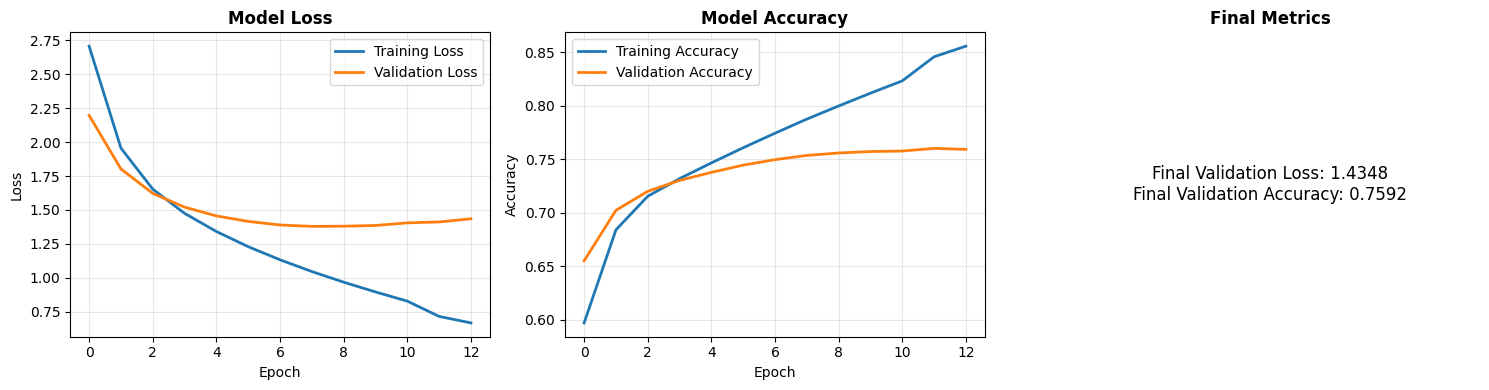


📊 Final Training Metrics:
----------------------------------------
Best Validation Loss: 1.3787
Best Validation Accuracy: 0.7601
Final Training Loss: 0.6670
Final Validation Loss: 1.4348
Final Training Accuracy: 0.8558
Final Validation Accuracy: 0.7592


In [11]:
def plot_training_history(history):
    """Plot training history with enhanced visualization"""
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Plot loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot accuracy
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title('Model Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot learning rate if available
    if 'lr' in history.history:
        axes[2].plot(history.history['lr'], linewidth=2, color='green')
        axes[2].set_title('Learning Rate', fontsize=12, fontweight='bold')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Learning Rate')
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)
    else:
        # Show final metrics
        final_loss = history.history['val_loss'][-1]
        final_acc = history.history['val_accuracy'][-1]
        axes[2].text(0.5, 0.5, f'Final Validation Loss: {final_loss:.4f}\nFinal Validation Accuracy: {final_acc:.4f}',
                    ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
        axes[2].set_title('Final Metrics', fontsize=12, fontweight='bold')
        axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Print final metrics
    print("\n📊 Final Training Metrics:")
    print("-" * 40)
    print(f"Best Validation Loss: {min(history.history['val_loss']):.4f}")
    print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
    print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

# Plot training history
plot_training_history(history)

In [18]:
def create_inference_models(model, config):
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input
    import tensorflow as tf

    print("\n🔍 Analyzing model architecture...")

    # Print model layers
    print("\nModel layers:")
    for i, layer in enumerate(model.layers):
        print(f"  {i}: {layer.name} - {layer.__class__.__name__}")

    # Encoder input
    encoder_input = model.input[0]

    # Get LSTM layers
    lstm_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.LSTM)]
    print(f"\nFound {len(lstm_layers)} LSTM layers")

    if len(lstm_layers) < 2:
        raise ValueError("Need at least 2 LSTM layers")

    encoder_lstm = lstm_layers[0]
    decoder_lstm = lstm_layers[1]

    # Get embedding layers
    embedding_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Embedding)]
    decoder_embedding = embedding_layers[1]

    # Get dense layer
    dense_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.Dense)][0]

    # ================== FIXED PART ==================
    print("\n🏗️ Creating encoder model...")

    # Correct way to get states
    encoder_outputs, state_h, state_c = encoder_lstm.output

    encoder_model = Model(
        inputs=encoder_input,
        outputs=[state_h, state_c]
    )

    print("✅ Encoder model created")

    # ================== DECODER ==================
    print("\n🏗️ Creating decoder model...")

    decoder_inputs = Input(shape=(1,), name='decoder_input')

    decoder_state_input_h = Input(shape=(config.HIDDEN_UNITS,), name='input_h')
    decoder_state_input_c = Input(shape=(config.HIDDEN_UNITS,), name='input_c')

    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

    decoder_emb = decoder_embedding(decoder_inputs)

    decoder_outputs, state_h, state_c = decoder_lstm(
        decoder_emb,
        initial_state=decoder_states_inputs
    )

    decoder_outputs = dense_layer(decoder_outputs)

    decoder_model = Model(
        [decoder_inputs] + decoder_states_inputs,
        [decoder_outputs, state_h, state_c],
        name='decoder_model'
    )

    print("✅ Decoder model created")

    return encoder_model, decoder_model


# ================= RUN =================
print("🚀 Creating inference models...")

try:
    encoder_model, decoder_model = create_inference_models(model, ModelConfig)

    print("\n✅ Inference models created successfully!")
    print(f"Encoder output shape: {encoder_model.output_shape}")
    print(f"Decoder inputs: {[inp.shape for inp in decoder_model.inputs]}")

except Exception as e:
    print(f"\n❌ Error: {e}")
    print("\n🔄 Trying alternative method...")

    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, LSTM, Dense, Embedding

    # ✅ FIXED LAYER INDEXING
    encoder_embedding_weights = model.layers[2].get_weights()
    decoder_embedding_weights = model.layers[3].get_weights()
    encoder_lstm_weights = model.layers[4].get_weights()
    decoder_lstm_weights = model.layers[5].get_weights()
    decoder_dense_weights = model.layers[6].get_weights()

    # Encoder
    encoder_inputs = Input(shape=(ModelConfig.MAX_SEQ_LEN_INPUT,))
    encoder_embedding = Embedding(
        ModelConfig.VOCAB_SIZE_INPUT,
        ModelConfig.EMBEDDING_DIM,
        weights=encoder_embedding_weights,
        trainable=False
    )(encoder_inputs)

    encoder_lstm = LSTM(
        ModelConfig.HIDDEN_UNITS,
        return_state=True,
        weights=encoder_lstm_weights,
        trainable=False
    )

    _, state_h, state_c = encoder_lstm(encoder_embedding)
    encoder_model = Model(encoder_inputs, [state_h, state_c])

    # Decoder
    decoder_inputs = Input(shape=(1,))
    decoder_state_input_h = Input(shape=(ModelConfig.HIDDEN_UNITS,))
    decoder_state_input_c = Input(shape=(ModelConfig.HIDDEN_UNITS,))

    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

    decoder_embedding = Embedding(
        ModelConfig.VOCAB_SIZE_OUTPUT,
        ModelConfig.EMBEDDING_DIM,
        weights=decoder_embedding_weights,
        trainable=False
    )

    decoder_lstm = LSTM(
        ModelConfig.HIDDEN_UNITS,
        return_sequences=True,
        return_state=True,
        weights=decoder_lstm_weights,
        trainable=False
    )

    decoder_dense = Dense(
        ModelConfig.VOCAB_SIZE_OUTPUT,
        activation='softmax',
        weights=decoder_dense_weights,
        trainable=False
    )

    decoder_emb = decoder_embedding(decoder_inputs)

    decoder_outputs, state_h, state_c = decoder_lstm(
        decoder_emb,
        initial_state=decoder_states_inputs
    )

    decoder_outputs = decoder_dense(decoder_outputs)

    decoder_model = Model(
        [decoder_inputs] + decoder_states_inputs,
        [decoder_outputs, state_h, state_c]
    )

    print("✅ Alternative inference models created successfully!")


print("\n📊 Final Models Ready!")

🚀 Creating inference models...

🔍 Analyzing model architecture...

Model layers:
  0: input_layer - InputLayer
  1: input_layer_1 - InputLayer
  2: embedding - Embedding
  3: embedding_1 - Embedding
  4: lstm - LSTM
  5: lstm_1 - LSTM
  6: dense - Dense

Found 2 LSTM layers

🏗️ Creating encoder model...
✅ Encoder model created

🏗️ Creating decoder model...
✅ Decoder model created

✅ Inference models created successfully!
Encoder output shape: [(None, 512), (None, 512)]
Decoder inputs: [(None, 1), (None, 512), (None, 512)]

📊 Final Models Ready!


In [20]:
def translate_sentence(input_text, encoder_model, decoder_model, input_tokenizer, 
                       output_tokenizer, config):
    """
    Translate English sentence to Hindi
    """
    # Clean and tokenize input
    cleaned = clean_text(input_text)
    sequence = input_tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=config.MAX_SEQ_LEN_INPUT, padding='post')
    
    # Encode input
    states_value = encoder_model.predict(padded, verbose=0)
    
    # Prepare decoder input (start token)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = output_tokenizer.word_index.get('start', 1)
    
    # Decode step by step
    decoded_sentence = []
    stop_condition = False
    
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        
        # Get word with highest probability
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = output_tokenizer.index_word.get(sampled_token_index, '')
        
        if sampled_word == 'end' or len(decoded_sentence) > config.MAX_SEQ_LEN_OUTPUT:
            stop_condition = True
        else:
            decoded_sentence.append(sampled_word)
        
        # Update target sequence and states
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]
    
    return ' '.join(decoded_sentence)

# Test the translation function
test_sentences = [
    "how are you",
    "what is your name",
    "i am human",
    "thank you"
]

print("🔍 Testing Translation Function:")
print("=" * 50)

for test_sentence in test_sentences:
    translation = translate_sentence(
        test_sentence, encoder_model, decoder_model,
        input_tokenizer, output_tokenizer, ModelConfig
    )
    print(f"\n📝 English: {test_sentence}")
    print(f"🇮🇳 Hindi: {translation}")
    print("-" * 40)

🔍 Testing Translation Function:

📝 English: how are you
🇮🇳 Hindi: आप कैसे हैं                       
----------------------------------------

📝 English: what is your name
🇮🇳 Hindi: तुम्हारा नाम क्या है                      
----------------------------------------

📝 English: i am human
🇮🇳 Hindi: मैं हूँ                        
----------------------------------------

📝 English: thank you
🇮🇳 Hindi: धन्यवाद                         
----------------------------------------


In [21]:
def evaluate_on_samples(df, num_samples=5):
    """Evaluate translation on random samples from dataset"""
    
    # Get random samples
    samples = df.sample(min(num_samples, len(df)))
    
    print("📊 Model Evaluation on Dataset Samples:")
    print("=" * 60)
    
    for idx, row in samples.iterrows():
        english_text = row['clean_english']
        reference_hindi = row['clean_hindi']
        
        # Translate
        predicted_hindi = translate_sentence(
            english_text, encoder_model, decoder_model,
            input_tokenizer, output_tokenizer, ModelConfig
        )
        
        print(f"\n📝 Sample {idx}:")
        print(f"🇬🇧 English: {english_text}")
        print(f"🇮🇳 Reference: {reference_hindi}")
        print(f"🤖 Translated: {predicted_hindi}")
        print("-" * 60)

# Evaluate on samples
evaluate_on_samples(df, num_samples=5)

📊 Model Evaluation on Dataset Samples:

📝 Sample 104429:
🇬🇧 English: himal newspaper
🇮🇳 Reference: हिमाल खवर पत्रिका
🤖 Translated: पत्रिका                         
------------------------------------------------------------

📝 Sample 120423:
🇬🇧 English: this is a sensitive figure
🇮🇳 Reference: यह एक संवेदनशील आंकड़ा है
🤖 Translated: यह एक है                       
------------------------------------------------------------

📝 Sample 45709:
🇬🇧 English: after losing the majority when ministers resign then make shift government comes in to play or it come to power if prime minister dies
🇮🇳 Reference: बहुमत समाप्त हो जाने के बाद जब मंत्रि परिषद त्यागपत्र दे देती है तब कामचलाऊ सरकार अस्तित्व मे आती है अथवा प्रधानमंत्री की मृत्यु त्यागपत्र की दशा मे यह स्थिति आती है।
🤖 Translated: जब वाजपेयी सरकार को तो प्रधानमंत्री को मजबूर कर दिया जाए तो वह प्रधानमंत्री के हित में कटौती हो जाएगी      
------------------------------------------------------------

📝 Sample 36023:
🇬🇧 English: if you are get

🔄 Calculating BLEU scores on 50 samples...

📊 BLEU Score Results:
----------------------------------------
Average BLEU Score: 0.0558
Median BLEU Score: 0.0000
Standard Deviation: 0.1209
Min Score: 0.0000
Max Score: 0.5623


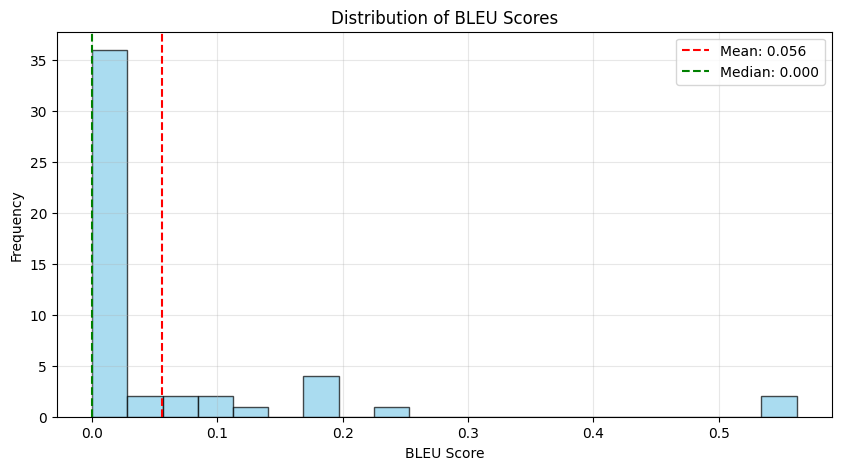

In [22]:
def calculate_bleu_scores(df, num_samples=100):
    """Calculate BLEU scores for model evaluation"""
    
    # Take a subset for evaluation
    eval_df = df.head(min(num_samples, len(df)))
    
    smoothing = SmoothingFunction().method1
    bleu_scores = []
    
    print(f"🔄 Calculating BLEU scores on {len(eval_df)} samples...")
    
    for idx, row in eval_df.iterrows():
        english_text = row['clean_english']
        reference = row['clean_hindi']
        
        # Translate
        predicted = translate_sentence(
            english_text, encoder_model, decoder_model,
            input_tokenizer, output_tokenizer, ModelConfig
        )
        
        # Calculate BLEU score
        reference_tokens = [reference.split()]
        predicted_tokens = predicted.split()
        
        try:
            bleu = sentence_bleu(reference_tokens, predicted_tokens, 
                               smoothing_function=smoothing)
            bleu_scores.append(bleu)
        except:
            bleu_scores.append(0.0)
    
    # Calculate statistics
    avg_bleu = np.mean(bleu_scores)
    median_bleu = np.median(bleu_scores)
    std_bleu = np.std(bleu_scores)
    
    print("\n📊 BLEU Score Results:")
    print("-" * 40)
    print(f"Average BLEU Score: {avg_bleu:.4f}")
    print(f"Median BLEU Score: {median_bleu:.4f}")
    print(f"Standard Deviation: {std_bleu:.4f}")
    print(f"Min Score: {min(bleu_scores):.4f}")
    print(f"Max Score: {max(bleu_scores):.4f}")
    
    # Plot distribution
    plt.figure(figsize=(10, 5))
    plt.hist(bleu_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(avg_bleu, color='red', linestyle='--', label=f'Mean: {avg_bleu:.3f}')
    plt.axvline(median_bleu, color='green', linestyle='--', label=f'Median: {median_bleu:.3f}')
    plt.xlabel('BLEU Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of BLEU Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return bleu_scores

# Calculate BLEU scores (use fewer samples if it's slow)
bleu_scores = calculate_bleu_scores(df, num_samples=50)

In [24]:
import pickle

def save_all_models(model, encoder_model, decoder_model, input_tokenizer, output_tokenizer, config):
    """Save all models and tokenizers"""
    
    # Create models directory if it doesn't exist
    os.makedirs('saved_models', exist_ok=True)
    
    # Save the models
    model.save('saved_models/seq2seq_translator.h5')
    encoder_model.save('saved_models/encoder_model.h5')
    decoder_model.save('saved_models/decoder_model.h5')
    
    # Save tokenizers
    with open('saved_models/input_tokenizer.pickle', 'wb') as handle:
        pickle.dump(input_tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
    with open('saved_models/output_tokenizer.pickle', 'wb') as handle:
        pickle.dump(output_tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
    # Save config
    with open('saved_models/config.pickle', 'wb') as handle:
        pickle.dump(config, handle)
    
    print("\n💾 Models and tokenizers saved successfully!")
    print("📁 Location: './saved_models/'")
    print("   - seq2seq_translator.h5")
    print("   - encoder_model.h5")
    print("   - decoder_model.h5")
    print("   - input_tokenizer.pickle")
    print("   - output_tokenizer.pickle")
    print("   - config.pickle")

# Save all models
save_all_models(model, encoder_model, decoder_model, input_tokenizer, output_tokenizer, ModelConfig)


💾 Models and tokenizers saved successfully!
📁 Location: './saved_models/'
   - seq2seq_translator.h5
   - encoder_model.h5
   - decoder_model.h5
   - input_tokenizer.pickle
   - output_tokenizer.pickle
   - config.pickle


In [25]:
def load_saved_models():
    """Load previously saved models and tokenizers"""
    
    from tensorflow.keras.models import load_model
    
    print("🔄 Loading saved models...")
    
    # Load models
    model = load_model('saved_models/seq2seq_translator.h5')
    encoder_model = load_model('saved_models/encoder_model.h5')
    decoder_model = load_model('saved_models/decoder_model.h5')
    
    # Load tokenizers
    with open('saved_models/input_tokenizer.pickle', 'rb') as handle:
        input_tokenizer = pickle.load(handle)
    
    with open('saved_models/output_tokenizer.pickle', 'rb') as handle:
        output_tokenizer = pickle.load(handle)
    
    # Load config
    with open('saved_models/config.pickle', 'rb') as handle:
        config = pickle.load(handle)
    
    print("✅ Models and tokenizers loaded successfully!")
    return model, encoder_model, decoder_model, input_tokenizer, output_tokenizer, config

# Uncomment to test loading
# loaded_model, loaded_encoder, loaded_decoder, loaded_input_tok, loaded_output_tok, loaded_config = load_saved_models()

In [26]:
def interactive_translator():
    """
    Interactive translation interface
    """
    print("\n" + "="*60)
    print("🌐 ENGLISH TO HINDI TRANSLATOR")
    print("="*60)
    print("Commands:")
    print("  - Type 'quit' to exit")
    print("  - Type 'save' to save translations to file")
    print("  - Type 'stats' to see session statistics")
    print("-"*60)
    
    saved_translations = []
    
    while True:
        english_text = input("\n📝 Enter English text: ").strip()
        
        if english_text.lower() == 'quit':
            if saved_translations:
                save_df = pd.DataFrame(saved_translations, columns=['English', 'Hindi'])
                save_df.to_csv('my_translations.csv', index=False)
                print(f"\n💾 Saved {len(saved_translations)} translations to 'my_translations.csv'")
            print("👋 Goodbye! धन्यवाद!")
            break
        
        if english_text.lower() == 'save':
            if saved_translations:
                save_df = pd.DataFrame(saved_translations, columns=['English', 'Hindi'])
                save_df.to_csv('my_translations.csv', index=False)
                print(f"💾 Saved {len(saved_translations)} translations to 'my_translations.csv'")
            else:
                print("No translations to save yet")
            continue
        
        if english_text.lower() == 'stats':
            if saved_translations:
                print(f"\n📊 Session Statistics:")
                print(f"Total translations: {len(saved_translations)}")
                print(f"Last translation: {saved_translations[-1][0]} -> {saved_translations[-1][1]}")
            else:
                print("No translations yet")
            continue
        
        if not english_text:
            print("⚠️ Please enter some text")
            continue
        
        # Translate
        print("🔄 Translating...", end=" ")
        try:
            hindi_text = translate_sentence(
                english_text, encoder_model, decoder_model,
                input_tokenizer, output_tokenizer, ModelConfig
            )
            print("Done!")
            
            print(f"\n🇬🇧 English: {english_text}")
            print(f"🇮🇳 Hindi: {hindi_text}")
            
            # Option to save
            save_choice = input("\n💾 Save this translation? (y/n): ").lower()
            if save_choice == 'y':
                saved_translations.append([english_text, hindi_text])
                print("✅ Saved!")
            
        except Exception as e:
            print(f"❌ Error: {e}")
            print("Please try again with a different sentence")
        
        print("-"*60)

# Run interactive translator
print("\n🚀 Starting Interactive Translator...")
interactive_translator()


🚀 Starting Interactive Translator...

🌐 ENGLISH TO HINDI TRANSLATOR
Commands:
  - Type 'quit' to exit
  - Type 'save' to save translations to file
  - Type 'stats' to see session statistics
------------------------------------------------------------
🔄 Translating... Done!

🇬🇧 English: hi how are you?
🇮🇳 Hindi: आप कैसे हैं                       
✅ Saved!
------------------------------------------------------------
⚠️ Please enter some text
⚠️ Please enter some text
⚠️ Please enter some text
⚠️ Please enter some text
🔄 Translating... Done!

🇬🇧 English: what are you doing
🇮🇳 Hindi: तुम क्या कर रहे हो                     
✅ Saved!
------------------------------------------------------------
⚠️ Please enter some text


KeyboardInterrupt: Interrupted by user

In [27]:
def quick_translate(text):
    """
    Quick and easy translation function
    Usage: quick_translate("hello world")
    """
    if not text or not isinstance(text, str):
        return ""
    
    try:
        translation = translate_sentence(
            text, encoder_model, decoder_model,
            input_tokenizer, output_tokenizer, ModelConfig
        )
        return translation
    except Exception as e:
        print(f"Translation error: {e}")
        return ""

# Test quick translate
print("🔍 Testing quick_translate function:")
print("-" * 40)
test_phrases = [
    "hello",
    "how are you",
    "what is your name",
    "good night",
    "see you later"
]

for phrase in test_phrases:
    result = quick_translate(phrase)
    print(f"'{phrase}' -> '{result}'")

🔍 Testing quick_translate function:
----------------------------------------
'hello' -> '                         '
'how are you' -> 'आप कैसे हैं                       '
'what is your name' -> 'तुम्हारा नाम क्या है                      '
'good night' -> '                         '
'see you later' -> 'यह भी देखें                       '


In [28]:
# Display final model information
print("="*60)
print("📊 FINAL MODEL SUMMARY")
print("="*60)

print("\n🎯 Model Architecture:")
print(f"  - Input vocabulary size: {ModelConfig.VOCAB_SIZE_INPUT:,}")
print(f"  - Output vocabulary size: {ModelConfig.VOCAB_SIZE_OUTPUT:,}")
print(f"  - Max English sequence length: {ModelConfig.MAX_SEQ_LEN_INPUT}")
print(f"  - Max Hindi sequence length: {ModelConfig.MAX_SEQ_LEN_OUTPUT}")
print(f"  - Embedding dimension: {ModelConfig.EMBEDDING_DIM}")
print(f"  - LSTM hidden units: {ModelConfig.HIDDEN_UNITS}")
print(f"  - Total trainable parameters: {model.count_params():,}")

print("\n💾 Saved Files:")
print("  - best_translation_model.h5 (best checkpoint)")
print("  - training_history.png (training plots)")
print("  - saved_models/ (directory with all models)")
print("  - my_translations.csv (your saved translations)")

print("\n📝 Usage Examples:")
print("  1. Interactive mode: Run Cell 18")
print("  2. Quick translate: quick_translate('your text here')")
print("  3. Batch translate: Use translate_sentence() function")

print("\n✅ Setup Complete! Your English to Hindi Translator is ready!")

📊 FINAL MODEL SUMMARY

🎯 Model Architecture:
  - Input vocabulary size: 5,000
  - Output vocabulary size: 5,000
  - Max English sequence length: 20
  - Max Hindi sequence length: 25
  - Embedding dimension: 256
  - LSTM hidden units: 512
  - Total trainable parameters: 8,274,824

💾 Saved Files:
  - best_translation_model.h5 (best checkpoint)
  - training_history.png (training plots)
  - saved_models/ (directory with all models)
  - my_translations.csv (your saved translations)

📝 Usage Examples:
  1. Interactive mode: Run Cell 18
  2. Quick translate: quick_translate('your text here')
  3. Batch translate: Use translate_sentence() function

✅ Setup Complete! Your English to Hindi Translator is ready!
